In [1]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
from brokenaxes import brokenaxes
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
import math
from Utils import *
from matplotlib.ticker import FuncFormatter
def format_k(value, tick_number):
    return f"{value / 1000:.1f}k"
formatter = FuncFormatter(format_k)
data_path = "quantum_network_compiler-minimal_codes/FIG_dataset_rebuttal"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cache_size'
data_path_list = [data_path+'/inter_time', data_path+'/exter_time', data_path + '/commqbit_num']
benchmark = ['xor','qft','grover','rca']
eval = ['inter_time','exter_time','commqbit_num']
inrack_reconfig = [0.05,0.1,0.2,0.4,0.6,0.8,1]
crossrack_reconfig = [5,10,15,20,25,30,35,40,45,50]
communication_qubit_num = [1,2,3,4,5,6]
tick_font = 20
labelpad = 10
line_width = 3
marker_size = 8

label_mapping = {
    "Benchmark-0": "MCT",
    "Benchmark-0-baseline": "MCT-baseline",
    "Benchmark-1": "QFT",
    "Benchmark-1-baseline": "QFT-baseline",
    "Benchmark-2": "Grover",
    "Benchmark-2-baseline": "Grover-baseline",
    "Benchmark-3": "RCA",
    "Benchmark-3-baseline": "RCA-baseline"
}

def set_ax(ax, idx, x_coor, desired_yticks):
    if idx == 0:  # 上面的子图
        # 设置左、上、右边框
        for spine in ['left', 'top', 'right']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1.5)
        # 隐藏下边框
        ax.spines['bottom'].set_visible(False)
    if idx == 1:  # 下面的子图
        # 设置左、下、右边框
        for spine in ['left', 'bottom', 'right']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1.5)
    ax.yaxis.set_major_locator(FixedLocator(desired_yticks))
    ax.xaxis.set_major_locator(FixedLocator(x_coor))
    ax.yaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelsize=tick_font) 
    ax.tick_params(axis='y', labelsize=tick_font) 

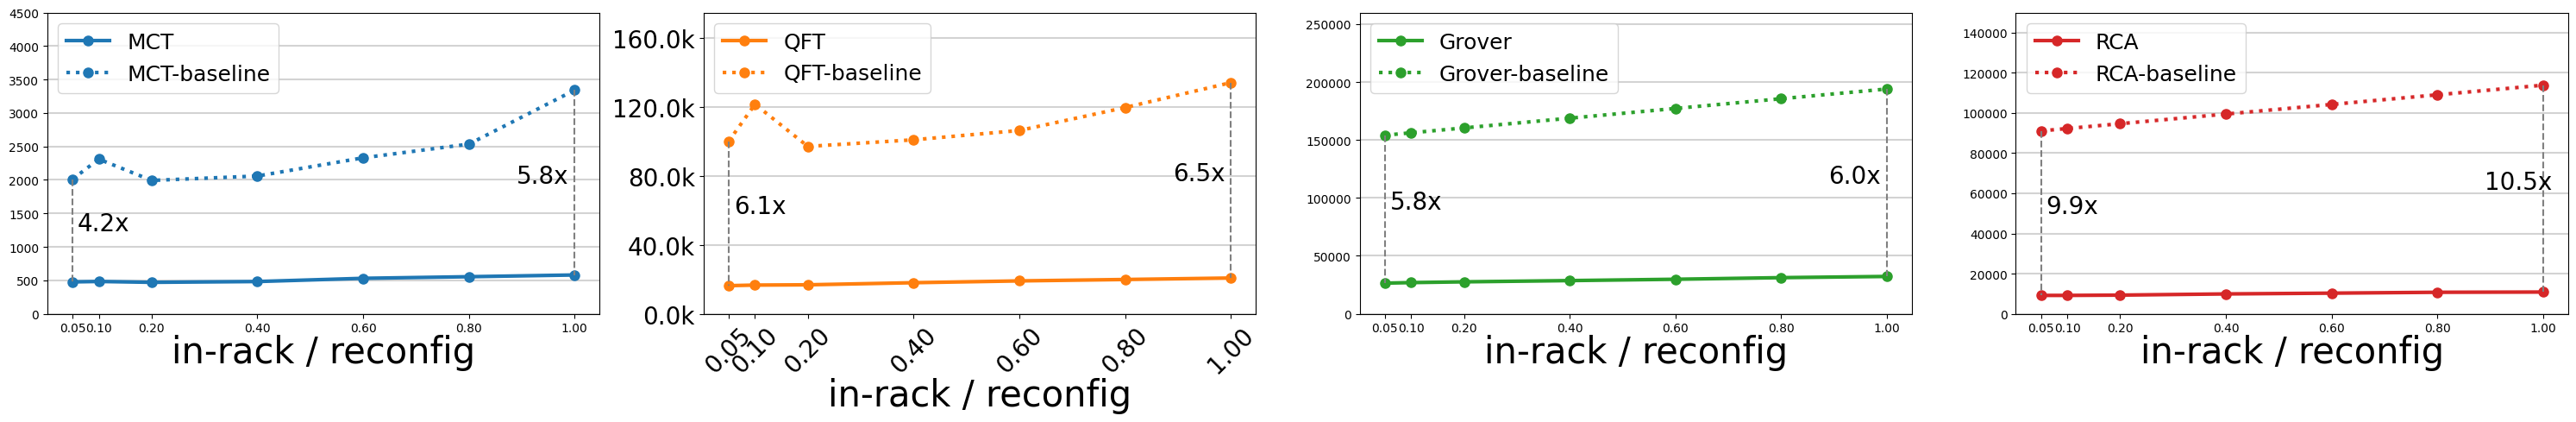

In [2]:
import matplotlib.pyplot as plt
import numpy as np
benchmark_names = ['MCT', 'QFT', 'Grover', 'RCA']
diction_our_1, diction_baseline_1 = compute_dictionaries(data_path_list[0], eval[0], benchmark)
ylim_list = [
    [(0, 4500), (0,175000), (0,260000), (0,150000)],     # FIG9 - a ylim
    [(0, 4000), (0,310000), (0,220000), (0,140000)], # FIG9 - b ylim
    [(0, 4000), (0, 180000), (0, 120000), (0, 60000)]   # FIG9 - c ylim
]
diction_our = [
    [
        [layer[benchmark_idx][i]/10 for i in [3, 6, 7, 8, 9, 10, 11]]
        for benchmark_idx in range(4)
    ]
    for layer in diction_our_1
]
diction_baseline = [
    [
        [layer[benchmark_idx][i]/10 for i in [3, 6, 7, 8, 9, 10, 11]]
        for benchmark_idx in range(4)
    ]
    for layer in diction_baseline_1
]
    

def set_axs_i(axs, i):
    axs[i].yaxis.set_major_locator(FixedLocator(desired_yticks))
    axs[i].xaxis.set_major_locator(FixedLocator(inrack_reconfig))
    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].tick_params(axis='x', labelsize=20,rotation = 45) 
    axs[i].tick_params(axis='y', labelsize=20) 

fig, axs = fig, axs = plt.subplots(1, 4, figsize=(30, 5))
for benchmark_idx, benchmark_name in enumerate(benchmark_names):
        ax = axs[benchmark_idx]
        ax.plot(inrack_reconfig, diction_our[0][benchmark_idx], label=f'{benchmark_name}', color=f'C{benchmark_idx}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_size)
        ax.plot(inrack_reconfig, [a for a in diction_baseline[0][benchmark_idx]], label=f'{benchmark_name}-baseline', color=f'C{benchmark_idx}', marker='o', linestyle='dotted', linewidth=line_width, markersize=marker_size)
        ax.text(inrack_reconfig[-1]-0.11,(diction_our[0][benchmark_idx][-1]+diction_baseline[0][benchmark_idx][-1])/2, f'{diction_baseline[0][benchmark_idx][-1]/diction_our[0][benchmark_idx][-1]:.1f}x',fontsize=20)
        ax.vlines(x=inrack_reconfig[-1], ymin=diction_baseline[0][benchmark_idx][-1], ymax=diction_our[0][benchmark_idx][-1], colors='gray', linestyles='dashed', linewidth=1.5)  
        ax.text(inrack_reconfig[0]+0.01,(diction_our[0][benchmark_idx][0]+diction_baseline[0][benchmark_idx][0])/2, f'{diction_baseline[0][benchmark_idx][0]/diction_our[0][benchmark_idx][0]:.1f}x',fontsize=20)
        ax.vlines(x=inrack_reconfig[0], ymin=diction_baseline[0][benchmark_idx][0], ymax=diction_our[0][benchmark_idx][0], colors='gray', linestyles='dashed', linewidth=1.5)  
        ax.legend(fontsize=18, loc='upper left')
        ax.set_xlabel('in-rack / reconfig', fontsize=30, color='black',labelpad=0)
        ax.grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray')
        ax.set_xticks(inrack_reconfig)
        ax.set_ylim(ylim_list[0][benchmark_idx])

#desired_yticks = [0,1000,2000,3000,4000]
#set_axs_i(axs, 0)
#axs[0].set_ylabel('latency', fontsize=30, color='black',labelpad=10)

desired_yticks = [0,40000,80000,120000,160000]
set_axs_i(axs, 1)

#desired_yticks = [0,60000,120000,180000,240000,300000]
#set_axs_i(axs, 2)

#desired_yticks = [0,40000,80000,120000,160000]
#set_axs_i(axs, 3)

plt.tight_layout()
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0, 0, 30, 5)

plt.savefig('fig/FIG_9c.pdf', bbox_inches=bbox)
plt.show()


NameError: name 'xlabel' is not defined

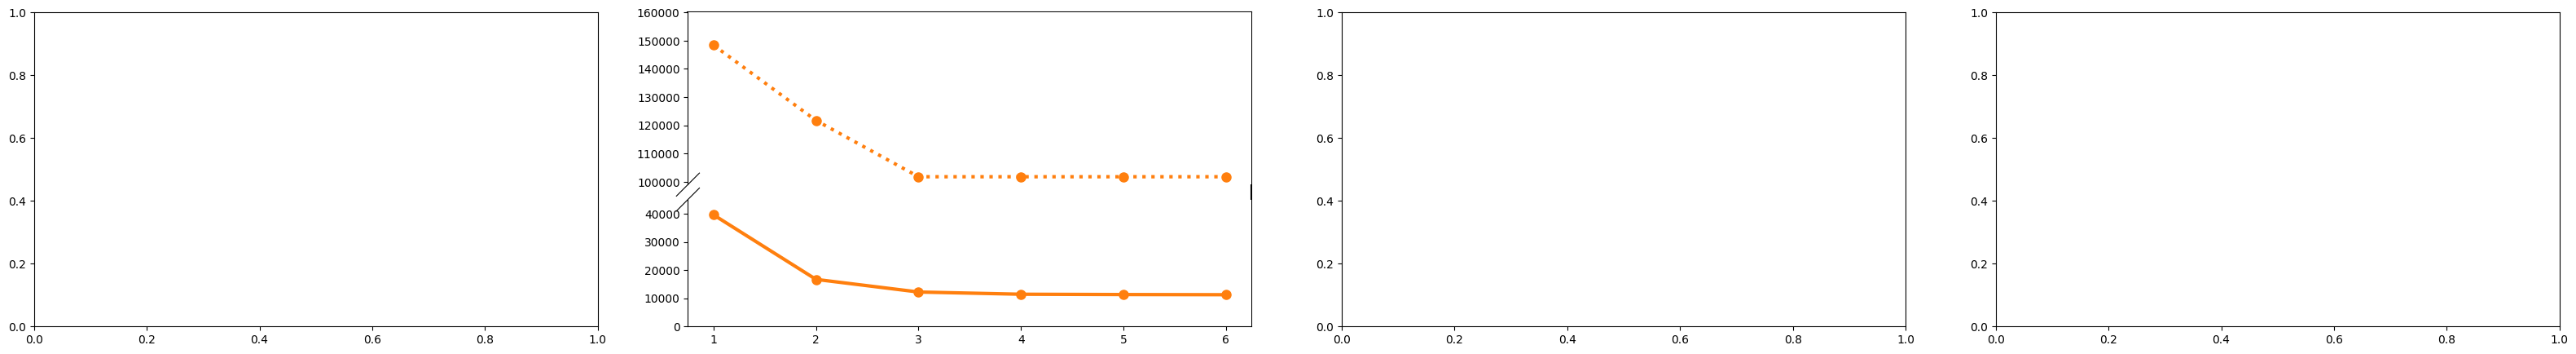

In [3]:
benchmark_names = ['MCT', 'QFT', 'Grover', 'RCA']
fig, axs = plt.subplots(1, 4, figsize=(40, 5), gridspec_kw={'wspace': 0.16})
normalize = False
diction_our, diction_baseline = compute_dictionaries(data_path_list[2], eval[2], benchmark)
x_coor = communication_qubit_num

def set_broken_axs_i(axs, i):
    axs[i].spines['top'].set_visible(True)
    axs[i].spines['top'].set_color('black')
    axs[i].spines['top'].set_linewidth(1.5)
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    axs[i].spines['right'].set_visible(True)
    axs[i].spines['right'].set_color('black')
    axs[i].spines['right'].set_linewidth(1.5)
    axs[i].tick_params(left=False, bottom=False) 
    axs[i].set_yticklabels([])                   
    axs[i].set_xticklabels([]) 

def set_bax(bax, i):
    bax.plot(x_coor, diction_our[0][i], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_size)
    bax.plot(x_coor, diction_baseline[0][i], 
            label=label_mapping[baseline_key], color=f'C{i}', marker='o', linestyle='dotted', linewidth=line_width, markersize=marker_size)
    bax.set_xlabel(xlabel, fontsize=30, color='black',labelpad=30)
    bax.vlines(x_coor[0],ymin = diction_baseline[0][i][0], ymax = diction_our[0][i][0],  colors='gray', linestyles='dashed', linewidth=1.5)
    bax.vlines(x_coor[-1],ymin = diction_baseline[0][i][-1], ymax = diction_our[0][i][-1],  colors='gray', linestyles='dashed', linewidth=1.5)
    bax.legend(fontsize=20, loc='upper right', framealpha=0.5)
    bax.grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray')
    
def set_axs_i(axs, i):
    axs[i].plot(x_coor, diction_our[0][i], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_size)
    axs[i].plot(x_coor, diction_baseline[0][i], 
            label=label_mapping[baseline_key], color=f'C{i}', marker='o', linestyle='dotted', linewidth=line_width, markersize=marker_size)
    axs[i].legend(fontsize=20, loc='upper right', framealpha=0.5)
    axs[i].set_xlabel(xlabel, fontsize=30, color='black',labelpad=0)
    axs[i].yaxis.set_major_locator(FixedLocator(desired_yticks))
    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].tick_params(axis='x', labelsize=tick_font) 
    axs[i].tick_params(axis='y', labelsize=tick_font) 
    axs[i].vlines(x_coor[0],ymin = diction_baseline[0][i][0], ymax = diction_our[0][i][0],  colors='gray', linestyles='dashed', linewidth=1.5)
    axs[i].vlines(x_coor[-1],ymin = diction_baseline[0][i][-1], ymax = diction_our[0][i][-1],  colors='gray', linestyles='dashed', linewidth=1.5)
    axs[i].grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray')
    axs[i].text(x_coor[0],(diction_baseline[0][i][0]+diction_our[0][i][0])/2+0.1,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
    axs[i].text(x_coor[-1]-0.5,(diction_baseline[0][i][-1]+diction_our[0][i][-1])/2-0.8,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)



#i = 0
#d = 0.005
#label_key = f"Benchmark-{i}"
#baseline_key = f"Benchmark-{i}-baseline"
#ylabel1 = 'latency'
#xlabel = 'communication qubit number'
#ss = axs[i].get_subplotspec()
#set_broken_axs_i(axs, i)
#bax = brokenaxes(ylims = ((0,1100),(2000,3600)), hspace = 0.1, subplot_spec = ss,fig = fig, d = d)
#set_bax(bax, i)
#bax.set_ylabel(ylabel1, fontsize=30, color='black', labelpad=60)
#bax.vlines(x_coor[-6],ymin = 0, ymax = 2, colors='gray', linestyles='dashed', linewidth=1.5)
#desired_yticks = [0,500,1000,2200,2700,3200,3700]
#bax.text(x_coor[0],2450,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
#bax.text(x_coor[-1]-0.5,900,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
#for idx, ax in enumerate(bax.axs):
#    set_ax(ax, idx, x_coor, desired_yticks)


i = 1
d = 0.005
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
ss = axs[i].get_subplotspec()
set_broken_axs_i(axs, i)
      
bax = brokenaxes(ylims=((0,45000),(99000,160000)), hspace=0.1, subplot_spec=ss, fig=fig, d=d)
set_bax(bax, i)
bax.vlines(x_coor[2],ymin = 0, ymax = 1, colors='gray', linestyles='dashed', linewidth=1.5)
bax.text(x_coor[0],115000,f'{diction_baseline[0][i][0]/diction_our[0][i][0]:.1f}x',fontsize = 20)
bax.text(x_coor[-1]-0.5,30000,f'{diction_baseline[0][i][-1]/diction_our[0][i][-1]:.1f}x',fontsize = 20)
desired_yticks = [0,20000,40000,110000,130000,150000,170000]
for idx, ax in enumerate(bax.axs):
    set_ax(ax, idx, x_coor, desired_yticks)


i = 2
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
axs[i].set_ylim(0,235000)
desired_yticks = [0,40000,80000,120000,160000,200000,240000]
set_axs_i(axs, i)


i = 3
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
desired_yticks = [0,20000,40000,60000,80000,100000,120000]
set_axs_i(axs, i)
axs[i].set_ylim(0,105000)

plt.savefig('fig/FIG_9a.pdf', bbox_inches='tight')
plt.show()

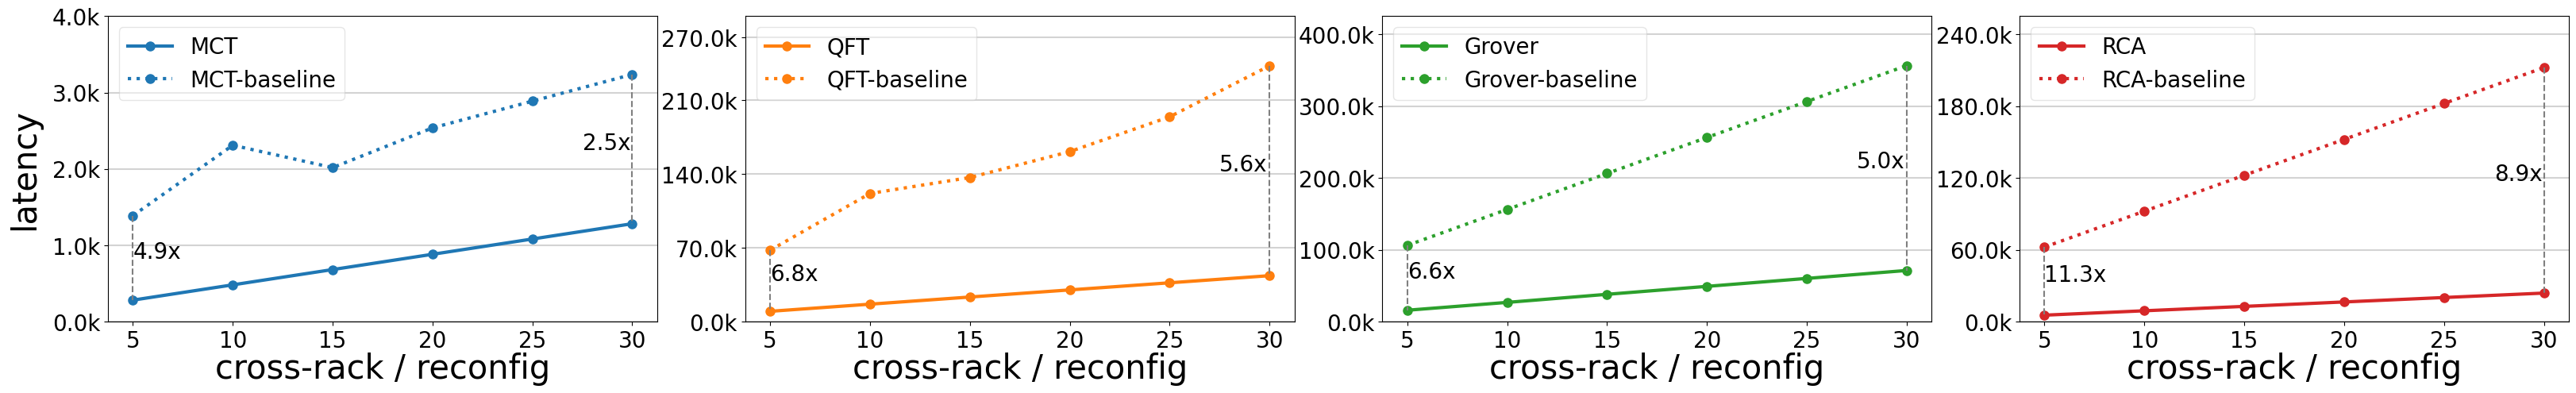

In [4]:
benchmark_names = ['MCT', 'QFT', 'Grover', 'RCA']
xlabel = 'cross-rack / reconfig'
ylabel1 ='latency'

fig, axs = plt.subplots(1, 4, figsize=(40, 5), gridspec_kw={'wspace': 0.16})
normalize = False
diction_our_2, diction_baseline_2 = compute_dictionaries(data_path_list[1], eval[1], benchmark)
x_coor = [5,10,15,20,25,30]
diction_our = [
    [
        [layer[benchmark_idx][i]/10 for i in range(len(layer[benchmark_idx]))]
        for benchmark_idx in range(4)
    ]
    for layer in diction_our_2
]
diction_baseline = [
    [
        [layer[benchmark_idx][i]/10 for i in range(len(layer[benchmark_idx]))]
        for benchmark_idx in range(4)
    ]
    for layer in diction_baseline_2
]

def set_axs_i(axs, i):
    axs[i].plot(x_coor, diction_our[0][i][2:8], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_size)
    axs[i].plot(x_coor, diction_baseline[0][i][2:8], 
            label=label_mapping[baseline_key], color=f'C{i}', marker='o', linestyle='dotted', linewidth=line_width, markersize=marker_size)
    axs[i].set_xlabel(xlabel, fontsize=30, color='black',labelpad=30)
    axs[i].legend(fontsize=20, loc='upper left', framealpha=0.5)
    axs[i].set_xlabel(xlabel, fontsize=30, color='black',labelpad=0)
    axs[i].yaxis.set_major_locator(FixedLocator(desired_yticks))
    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].tick_params(axis='x', labelsize=tick_font) 
    axs[i].tick_params(axis='y', labelsize=tick_font) 
    axs[i].vlines(x_coor[0],ymin = diction_baseline[0][i][2], ymax = diction_our[0][i][2],  colors='gray', linestyles='dashed', linewidth=1.5)
    axs[i].vlines(x_coor[-1],ymin = diction_baseline[0][i][7], ymax = diction_our[0][i][7],  colors='gray', linestyles='dashed', linewidth=1.5)
    axs[i].text(x_coor[0],(diction_baseline[0][i][2]+diction_our[0][i][2])/2+0.1,f'{diction_baseline[0][i][2]/diction_our[0][i][2]:.1f}x',fontsize = 20)
    axs[i].text(x_coor[-1]-2.5,(diction_baseline[0][i][7]+diction_our[0][i][7])/2-0.8,f'{diction_baseline[0][i][7]/diction_our[0][i][7]:.1f}x',fontsize = 20)
    axs[i].grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray')

i = 0
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
desired_yticks = [0,1000,2000,3000,4000]
axs[i].set_ylim(0,4000)
axs[i].set_ylabel(ylabel1, fontsize=30, color='black', labelpad=10)
set_axs_i(axs, i)

i = 1
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
desired_yticks = [0,70000,140000,210000,270000]
axs[i].set_ylim(0,290000)
set_axs_i(axs, i)

i = 2
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
axs[i].set_ylim(0,425000)
desired_yticks = [0,100000,200000,300000,400000]
set_axs_i(axs, i)

i = 3
label_key = f"Benchmark-{i}"
baseline_key = f"Benchmark-{i}-baseline"
desired_yticks = [0,60000,120000,180000,240000]
axs[i].set_ylim(0,255000)
set_axs_i(axs, i)

plt.savefig('fig/FIG_9b.pdf', bbox_inches='tight')
plt.show()